In [41]:
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
import scipy.stats as stats
from scipy import stats
import seaborn as sns
import warnings
import pendulum

### 数据导入及预处理

In [2]:
df1=pd.read_excel('./附件1.xlsx')

In [3]:
df2=pd.read_excel('./附件2(2).xlsx')

In [4]:
df3=pd.read_excel('./附件3(2).xlsx')

In [5]:
df4=pd.read_excel('./附件4.xlsx')

In [6]:
df2.head()
df2.columns = ['销售日期', '扫码销售时间','单品编码','单品名称','单品名称2','品类','分类编码','销量','销售单价','销售类型','是否打折销售']
df2.head()
df3.columns = ['日期','单品编码','单品名称','单品名称2','批发价格']
df3.head()
#把单品编码的数据类型改为字符串
print(df2.dtypes,'\n')
df1['单品编码'] = df1['单品编码'].astype(str)
df2['单品编码'] = df2['单品编码'].astype(str)
df2['分类编码'] = df2['分类编码'].astype(str)
df3['单品编码'] = df3['单品编码'].astype(str)
df4['单品编码'] = df4['单品编码'].astype(str)
print(df2.dtypes)
df3['日期'] = pd.to_datetime(df3['日期'])
df3['时间'] = 0
counter = 1
for index, row in df3.iterrows():
    if index == 0:
        df3.at[index, '时间'] = counter
    elif row['日期'] != df3.at[index - 1, '日期']:
        counter += 1
        df3.at[index, '时间'] = counter
    else:
        df3.at[index, '时间'] = counter
df3.insert(0, '时间', df3.pop('时间'))
df3

,销售日期,扫码销售时间,单品编码,单品名称,单品名称2,品类,分类编码,销量(千克),销售单价(元/千克),销售类型,是否打折销售
0,2020-07-01,09:15:07.924,102900005117056,泡泡椒(精品),泡泡椒,辣椒类,1011010504,0.396,7.6,销售,否
1,2020-07-01,09:17:27.295,102900005115960,大白菜,大白菜,花叶类,1011010101,0.849,3.2,销售,否
2,2020-07-01,09:17:33.905,102900005117056,泡泡椒(精品),泡泡椒,辣椒类,1011010504,0.409,7.6,销售,否
3,2020-07-01,09:19:45.450,102900005115823,上海青,上海青,花叶类,1011010101,0.421,10.0,销售,否
4,2020-07-01,09:20:23.686,102900005115908,菜心,菜心,花叶类,1011010101,0.539,8.0,销售,否


缺失值、异常值处理

In [ ]:
#缺失值统计
missing_values1 = df1.isna().sum()
missing_values2 = df2.isna().sum()
missing_values3 = df3.isna().sum()
missing_values4 = df4.isna().sum()
print('附件1缺失值统计：\n',missing_values1,'\n')
print('附件2缺失值统计：\n',missing_values2,'\n')
print('附件3缺失值统计：\n',missing_values3,'\n')
print('附件4缺失值统计：\n',missing_values4,'\n')
#异常值处理
#查看每样单品都被进货了多少次，是否都被进货过
value_count = df3['单品编码'].value_counts()
value_count = pd.DataFrame(value_count)
value_count.reset_index(inplace=True)
value_count.columns = ['单品编码','进货次数']
value_count['单品编码'] = value_count['单品编码'].astype(str)
value_count.to_excel('output.xlsx', index=False)
value_count


表的连接

In [ ]:
new_df3 = df3.copy()
group_df = new_df3.groupby('单品编码')

for group_name, group_data in group_df:
    price = group_data['批发价格']
    Q1 = price.quantile(0.25)
    Q3 = price.quantile(0.75)
    IQR = Q3 - Q1
    # 计算异常值的上下限
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    # 识别和替换异常值
    price = price.apply(lambda x: upper_limit if x > upper_limit else (lower_limit if x < lower_limit else x))
    new_df3.loc[group_data.index,'批发价格'] = price
new_df3.head()

### 问题1

#### 分析蔬菜单品分布规律

In [7]:
"""问题1：分析蔬菜单品分布规律"""
#修改数据类型
df2['单品编码'] = df2['单品编码'].astype(object)
df2['分类编码'] =df2['分类编码'].astype(object)


In [8]:
#统计进货次数
come_count = df3['单品名称2'].value_counts()
come_count_sorted = come_count.sort_values(ascending=False)
come_count

金针菇          1946
海鲜菇          1715
杏鲍菇          1658
螺丝椒          1302
云南生菜         1235
             ... 
芥兰              1
活体银耳            1
芝麻苋菜            1
洪山菜薹珍品手提袋       1
甘蓝叶             1
Name: 单品名称2, Length: 154, dtype: int64

In [9]:
#统计总销量确定选取的单品
sale_count = df2.groupby('单品名称2')['销量(千克)'].sum().reset_index()
sale_count.sort_values(by='销量(千克)',ascending=False)

,单品名称2,销量(千克)
5,云南生菜,30235.461
122,金针菇,28640.785
86,芜湖青椒,28164.331
9,净藕,27560.461
114,西兰花,27537.228
...,...,...
50,活体银耳,1.000
58,甘蓝叶,0.943
78,红珊瑚,0.682
88,芥兰,0.671


In [10]:
single_month = [[0] * 5] * 12
single_month = pd.DataFrame(single_month,index=range(1,13))
single_month.rename(columns={0: '金针菇', 1: '海鲜菇',2:'杏鲍菇',3:'螺丝椒',4:'云南生菜'}, inplace=True)
print(single_month.columns)
print(single_month.index)


Index(['金针菇', '海鲜菇', '杏鲍菇', '螺丝椒', '云南生菜'], dtype='object')
RangeIndex(start=1, stop=13, step=1)


In [11]:
item = 185834 #从这个开始2021第一单
year = df2['销售日期'][item].year
month = df2['销售日期'][item].month
while(year==2021):
    if(df2['单品名称2'][item]=='金针菇'):
        single_month.at[month,'金针菇']+=df2['销量(千克)'][item]
    if(df2['单品名称2'][item]=='海鲜菇'):
        single_month.at[month,'海鲜菇']+=df2['销量(千克)'][item] 
    if(df2['单品名称2'][item]=='杏鲍菇'):
        single_month.at[month,'杏鲍菇']+=df2['销量(千克)'][item]
    if(df2['单品名称2'][item]=='螺丝椒'):
        single_month.at[month,'螺丝椒']+=df2['销量(千克)'][item]
    if(df2['单品名称2'][item]=='云南生菜'):
        single_month.at[month,'云南生菜']+=df2['销量(千克)'][item]
    item+=1
    year = df2['销售日期'][item].year
    month = df2['销售日期'][item].month
single_month

,金针菇,海鲜菇,杏鲍菇,螺丝椒,云南生菜
1,720.649,297.476,232.527,133.139,382.120
2,1068.068,425.102,256.253,377.257,538.707
3,731.382,370.916,163.682,486.953,666.582
4,422.861,159.474,133.247,320.185,570.904
5,353.853,112.936,174.157,422.166,596.038
6,265.378,115.374,124.819,447.576,720.929
7,303.283,134.164,170.009,289.786,1287.410
8,383.212,194.734,277.878,190.035,1129.327
9,400.024,189.638,188.543,159.460,878.695
10,556.151,289.000,2.532,153.081,823.690


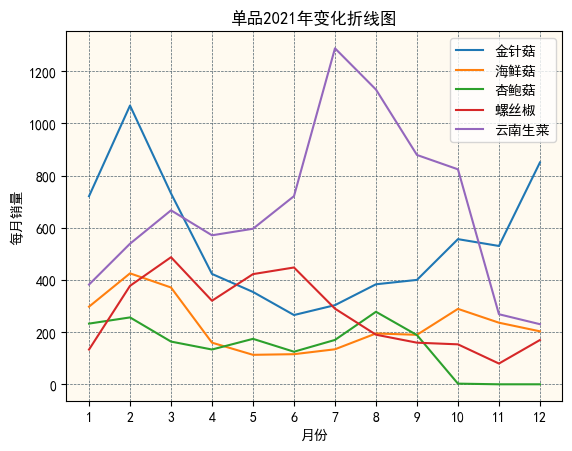

In [12]:
# 添加标题和标签
plt.plot(single_month,label=single_month.columns)
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用中文字体（例如宋体）
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
plt.title('单品2021年变化折线图')
plt.xlabel('月份')
plt.ylabel('每月销量')
plt.xticks(range(1,13))
# 添加图例
plt.legend()
# 显示图表
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.savefig('./单品2021年变化折线图.png',dpi=300)
plt.show()

In [13]:
#根据每日统计每个单品类的销售情况
single_day = [[0] * 5] * 13
single_day = pd.DataFrame(0, index=range(8, 25), columns=['云南生菜','金针菇','芜湖青椒','净藕','西兰花'])
print(single_day.columns)
print(single_day.index)

Index(['云南生菜', '金针菇', '芜湖青椒', '净藕', '西兰花'], dtype='object')
RangeIndex(start=8, stop=25, step=1)


In [14]:
item = 0 
hour = int(df2['扫码销售时间'][item][0:2],10)
count = [[0] * 5] * 13
count = pd.DataFrame(0, index=range(8, 25), columns=['云南生菜','金针菇','芜湖青椒','净藕','西兰花'])
flag = [0]*5#这个商品在某天这个时段出现了
while(item<=878502):
    if(df2['单品名称2'][item]=='云南生菜'):
        single_day.at[hour,'云南生菜']+=df2['销量(千克)'][item]
        flag[0]=1
    if(df2['单品名称2'][item]=='金针菇'):
        single_day.at[hour,'金针菇']+=df2['销量(千克)'][item] 
        flag[1]=1
    if(df2['单品名称2'][item]=='芜湖青椒'):
        single_day.at[hour,'芜湖青椒']+=df2['销量(千克)'][item]
        flag[2]=1
    if(df2['单品名称2'][item]=='净藕'):
        single_day.at[hour,'净藕']+=df2['销量(千克)'][item]
        flag[3]=1
    if(df2['单品名称2'][item]=='西兰花'):
        single_day.at[hour,'西兰花']+=df2['销量(千克)'][item]
        flag[4]=1
    #判断是否跨时
    hour1=hour
    item+=1
    if(item==878502):
        break
    day2 = df2['销售日期'][item].day         
    hour = int(df2['扫码销售时间'][item][0:2],10)
    if hour1!=hour:
        if(flag[0]==1):
            count.at[hour1,'云南生菜']+=1
        if(flag[1]==1):
            count.at[hour1,'金针菇']+=1
        if(flag[2]==1):
            count.at[hour1,'芜湖青椒']+=1
        if(flag[3]==1):
            count.at[hour1,'净藕']+=1
        if(flag[4]==1):
            count.at[hour1,'西兰花']+=1 
        flag[0]=0
        flag[1]=0
        flag[2]=0
        flag[3]=0
        flag[4]=0
single_day

,云南生菜,金针菇,芜湖青椒,净藕,西兰花
8,0.391,0.000,0.000,0.000,0.000
9,2464.343,1480.168,2167.429,3306.893,2076.534
10,3987.655,2928.765,3485.950,5450.423,3636.198
11,3037.369,2691.952,2790.547,3998.419,3027.916
12,1737.589,1660.032,1498.430,1882.162,1590.175
13,1192.861,1165.084,1122.136,1406.636,1218.537
14,1453.219,1396.375,1418.003,1467.721,1382.790
15,2124.249,2181.989,2087.782,2118.326,1950.421
16,2815.006,3028.365,2653.634,2547.964,2611.917
17,3189.434,3696.455,3052.893,2356.171,2938.986


    云南生菜  金针菇  芜湖青椒    净藕   西兰花
8      1    0     0     0     0
9    952  781   827   954   985
10  1028  911   838  1000  1032
11   970  871   836   934  1028
12   920  760   801   803   961
13   805  650   765   732   878
14   858  664   769   772   896
15   984  830   816   826   984
16   997  878   832   877  1008
17  1028  938   832   891  1021
18  1005  909   831   792  1024
19   939  810   818   503   962
20   768  701   795   228   882
21   408  391   645    57   502
22    17    9    19     1     4
23     0    0     0     0     0
24     0    0     0     0     0
        云南生菜       金针菇      芜湖青椒        净藕       西兰花
8   0.391000       NaN       NaN       NaN       NaN
9   2.588596  1.895222  2.620833  3.466345  2.108156
10  3.879042  3.214890  4.159845  5.450423  3.523448
11  3.131308  3.090645  3.337975  4.280963  2.945444
12  1.888684  2.184253  1.870699  2.343913  1.654709
13  1.481815  1.792437  1.466844  1.921634  1.387855
14  1.693728  2.102974  1.843957  1.901193  1.543292


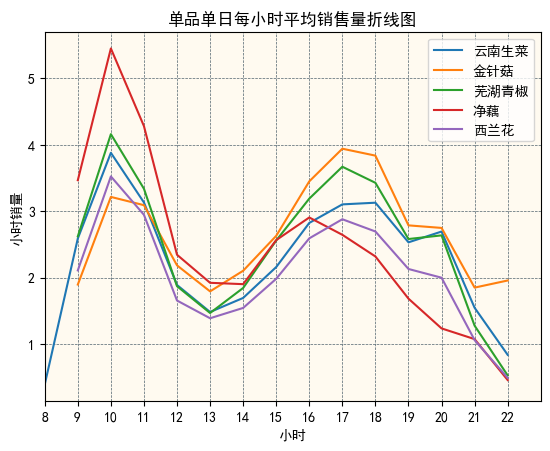

In [15]:
#求平均
print(count)
result = single_day.div(count)
print(result)
#画图
# 添加标题和标签
plt.plot(result,label=single_day.columns)
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用中文字体（例如宋体）
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
plt.title('单品单日每小时平均销售量折线图')
plt.xlabel('小时')
plt.ylabel('小时销量')
plt.xticks(range(8,23))
plt.xlim(8,23)
# 添加图例
plt.legend()
# 显示图表
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.savefig('./单品单日每小时平均销售量折线图.png',dpi=300)
plt.show()


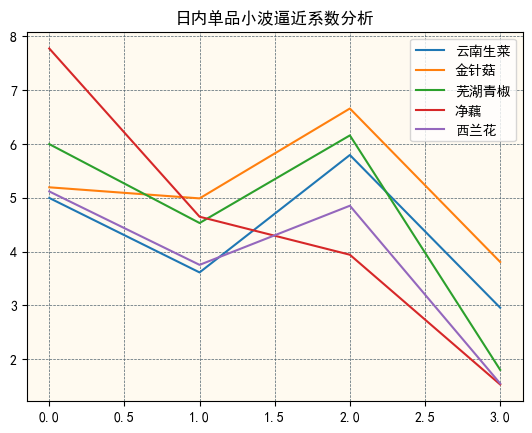

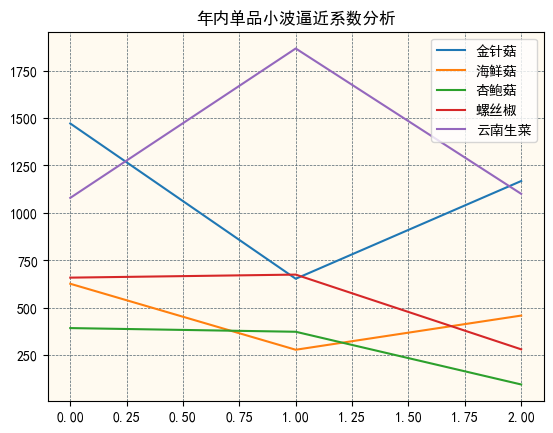

In [16]:
#对它进行小波分析
# 定义小波分析函数
def wavelet_analysis(data):
    # 使用小波变换
    coeffs = pywt.wavedec(data, 'haar', level=2)
    
    # 提取逼近系数和细节系数
    approx = coeffs[0][:len(data)]  # 确保长度匹配
    details = [coeff[:len(data)] for coeff in coeffs[1:]]  # 确保长度匹配
    
    return approx, details

# 对每个商品的小时销售数据进行粗略小波分析
a1=result['云南生菜'][:-2]
a2=result['金针菇'][1:-2]
a3=result['芜湖青椒'][1:-2]
a4=result['净藕'][1:-2]
a5=result['西兰花'][1:-2]
approx1, details1 = wavelet_analysis(a1)
approx2, details2 = wavelet_analysis(a2)
approx3, details3 = wavelet_analysis(a3)
approx4, details4 = wavelet_analysis(a4)
approx5, details5 = wavelet_analysis(a5)
plt.title('日内单品小波逼近系数分析')

plt.plot(approx1,label=single_day.columns[0])
plt.plot(approx2,label=single_day.columns[1])
plt.plot(approx3,label=single_day.columns[2])
plt.plot(approx4,label=single_day.columns[3])
plt.plot(approx5,label=single_day.columns[4])
plt.legend()
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.savefig('./日内单品小波逼近系数分析.png',dpi=300)
plt.show()

a1=single_month['金针菇']
a2=single_month['海鲜菇']
a3=single_month['杏鲍菇']
a4=single_month['螺丝椒']
a5=single_month['云南生菜']
approx1, details1 = wavelet_analysis(a1)
approx2, details2 = wavelet_analysis(a2)
approx3, details3 = wavelet_analysis(a3)
approx4, details4 = wavelet_analysis(a4)
approx5, details5 = wavelet_analysis(a5)
plt.title('年内单品小波逼近系数分析')
plt.plot(approx1,label=single_month.columns[0])
plt.plot(approx2,label=single_month.columns[1])
plt.plot(approx3,label=single_month.columns[2])
plt.plot(approx4,label=single_month.columns[3])
plt.plot(approx5,label=single_month.columns[4])
plt.legend()
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.savefig('./年内单品小波逼近系数分析.png',dpi=300)
plt.show()

    
    

#### 分析蔬菜各品类分布规律

In [ ]:
huaye = np.zeros(36)
huacai = np.zeros(36)
shuisheng = np.zeros(36)
qie = np.zeros(36)
lajiao = np.zeros(36)
jun = np.zeros(36)
total = np.zeros(36)
i = 0
month = 7
for index,row in df2.iterrows():
    if(month != row['销售日期'].month):
        month = row['销售日期'].month
        i += 1
    total[i] += row['销量']
    if(row['品类'] == '花叶类'):
        huaye[i] += row['销量']
    elif(row['品类'] == '花菜类'):
        huacai[i] += row['销量']
    elif(row['品类'] == '水生根茎类'):
        shuisheng[i] += row['销量']
    elif(row['品类'] == '茄类'):
        qie[i] += row['销量']
    elif(row['品类'] == '辣椒类'):
        lajiao[i] += row['销量']
    else:
        jun[i] += row['销量']
data = pd.concat([pd.Series(huaye), pd.Series(huacai), pd.Series(shuisheng),pd.Series(qie),pd.Series(lajiao),pd.Series(jun)], axis=1)
data.columns = ['花叶类','花菜类','水生根茎类','茄类','辣椒类','菌类']
data
for i in range(36):
    huaye[i] /= total[i]
    huacai[i] /= total[i]
    shuisheng[i] /= total[i]
    qie[i] /= total[i]
    lajiao[i] /= total[i]
    jun[i] /= total[i]
huaye

month =  np.array(range(1,37))

plt.figure(figsize=(15, 8))

plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.bar(month, huaye, label='花叶类',alpha=0.7,color='darkcyan')
plt.bar(month, huacai, bottom=huaye, label='花菜类',alpha=0.7,color='yellowgreen')
plt.bar(month, shuisheng,bottom=huaye+huacai, label='水生根茎类',alpha=0.7,color='dodgerblue')
plt.bar(month, qie,bottom=huaye+huacai+shuisheng, label='茄类',alpha=0.7,color='blueviolet')
plt.bar(month, lajiao,bottom=huaye+huacai+shuisheng+qie, label='辣椒类',alpha=0.7,color='hotpink')
plt.bar(month, jun,bottom=huaye+huacai+shuisheng+qie+lajiao, label='菌类',alpha=0.7,color='indianred')

# 添加标签和标题
plt.xlabel('月份',fontsize = 15)
plt.ylabel('销量占比 (%)',fontsize = 15)

# 添加图例
plt.legend()

# 调整 x 轴标签旋转角度（可选）
plt.xticks(rotation=90)

# 保存图片
plt.savefig('./各蔬菜品类每月销量分布.png',dpi=300)
plt.show()

for i in range(36):
    huaye[i] *= total[i]
    huacai[i] *= total[i]
    shuisheng[i] *= total[i]
    qie[i] *= total[i]
    lajiao[i] *= total[i]
    jun[i] *= total[i]
huaye

huaye2 = np.zeros(3)
huacai2 = np.zeros(3)
shuisheng2 = np.zeros(3)
qie2 = np.zeros(3)
lajiao2 = np.zeros(3)
jun2 = np.zeros(3)
total2 = np.zeros(3)
index = 0
for i in range(36):
    if(i % 12 == 0 and i!=0):
        index += 1
    huaye2[index] += huaye[i]
    huacai2[index] += huacai[i]
    shuisheng2[index] += shuisheng[i]
    qie2[index] += qie[i]
    lajiao2[index] += lajiao[i]
    jun2[index] += jun[i]
    total2[index] += total[i]
for i in range(3):
    huaye2[i] /= total2[i]
    huacai2[i] /= total2[i]
    shuisheng2[i] /= total2[i]
    qie2[i] /= total2[i]
    lajiao2[i] /= total2[i]
    jun2[i] /= total2[i]
year = np.array([0,1,2])
huaye2

plt.figure(figsize=(10, 7))

plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.bar(year, huaye2, label='花叶类',alpha=0.7,color='darkcyan')
plt.bar(year, huacai2, bottom=huaye2, label='花菜类',alpha=0.7,color='yellowgreen')
plt.bar(year, shuisheng2,bottom=huaye2+huacai2, label='水生根茎类',alpha=0.7,color='dodgerblue')
plt.bar(year, qie2,bottom=huaye2+huacai2+shuisheng2, label='茄类',alpha=0.7,color='blueviolet')
plt.bar(year, lajiao2,bottom=huaye2+huacai2+shuisheng2+qie2, label='辣椒类',alpha=0.7,color='hotpink')
plt.bar(year, jun2,bottom=huaye2+huacai2+shuisheng2+qie2+lajiao2, label='菌类',alpha=0.7,color='indianred')

# 添加标签和标题
plt.xlabel('年份',fontsize = 15)
plt.ylabel('销量占比 (%)',fontsize = 15)
# 添加图例
plt.legend()

# 调整 x 轴标签旋转角度（可选）
plt.xticks(rotation=90)

# 显示图形
plt.savefig('./各蔬菜品类每年销量分布.png',dpi=300)
plt.show()

#### 单品相互关系

In [ ]:
m = []
for i in range(20):
    m.append(np.zeros(36))
product_dict = {}    
product_dict['云南生菜'] = 0
product_dict['金针菇'] = 1
product_dict['芜湖青椒'] = 2
product_dict['净藕'] = 3
product_dict['西兰花'] = 4
product_dict['大白菜'] = 5
product_dict['云南油麦菜'] = 6
product_dict['螺丝椒'] = 7
product_dict['紫茄子'] = 8
product_dict['奶白菜'] = 9
product_dict['西峡香菇'] = 10
product_dict['小米椒'] = 11
product_dict['菠菜'] = 12
product_dict['上海青'] = 13
product_dict['泡泡椒'] = 14
product_dict['海鲜菇'] = 15
product_dict['娃娃菜'] = 16
product_dict['青梗散花'] = 17
product_dict['竹叶菜'] = 18
product_dict['黄白菜'] = 19
product_dict

i = 0
month = 7
for index,row in df2.iterrows():
    if(month != row['销售日期'].month):
        month = row['销售日期'].month
        i += 1
    if row['单品名称2'] in product_dict:
        value = product_dict[row['单品名称2']]
        m[value][i] += row['销量']
da
ta = np.array(m)
data = pd.DataFrame(data.T)
data.columns = sale_count.loc[:19]['单品名称2']
data.head()
corr1 = pd.DataFrame(data.corr(method='pearson'))

sns.set(font='SimHei')  # 解决Seaborn中文显示问题
plt.figure(figsize=(10, 7))
cols = data.columns
hm = sns.heatmap(corr1, yticklabels=cols.values, xticklabels=cols.values, cmap='YlGnBu_r')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.savefig('./单品销售量相关性分析.png', dpi=300)
plt.show()

df2['扫码销售时间'] = df2['扫码销售时间'].str.split('.').str[0]
df2['扫码销售时间'] = pd.to_datetime(df2['扫码销售时间'], format='%H:%M:%S')
df2.dtypes

item_set = []
item = set([])

for i,row in df2.iterrows():
    if(i==0 or (row['扫码销售时间'] - df2.loc[i-1]['扫码销售时间']).total_seconds() < 60):
        item.add(row['单品名称'])
    else:
        item_set.append(item)
        item = set([row['单品名称']])
item_set

#划分出来的订单量
len(item_set)

from FPGrowth import *

item_set = [list(s) for s in item_set]
support = 0.03
model = FPGrowth(support)
model.fit(item_set)
model.predict()

lst = [['紫茄子(2)','芜湖青椒(1)'],
       ['净藕(1)','西兰花','芜湖青椒(1)','西峡香菇(1)'],
       ['云南生菜','西兰花','芜湖青椒(1)','西峡香菇(1)'],
       ['西峡香菇(1)','西兰花','芜湖青椒(1)'],
       ['西兰花','芜湖青椒(1)']]
lift = pd.DataFrame({'关系':[],
                    '支持度':[]})

for i in range(len(lst)):
    total_A = 0
    for item in item_set:
        if(lst[i][0] in item):
            total_A += 1
    p_A = total_A / len(item_set)
    for j in range(1,len(lst[i])):
        total_B = 0
        total_AB = 0
        for item in item_set:
            if(lst[i][j] in item):
                total_B += 1
            if(lst[i][j] in item and lst[i][0] in item):
                total_AB += 1
        p_B = total_B / len(item_set)
        p_AB = total_AB / len(item_set)
        lift = lift.append({'关系':lst[i][0]+'-'+lst[i][j],
                           '支持度':p_AB / (p_A*p_B)},ignore_index=True)
lift

#### 品类相互关系

In [ ]:
corr2 = pd.DataFrame(data.corr(method='pearson'))

sns.set(font='SimHei')  # 解决Seaborn中文显示问题
plt.figure(figsize=(12, 8))
cols = data.columns
hm = sns.heatmap(corr2, yticklabels=cols.values, xticklabels=cols.values, cmap='YlGnBu_r')
plt.savefig('./品类销售量相关性分析.png', dpi=300)
plt.show()

item_set2 = []
item2 = set([])
for i,row in df2.iterrows():
    if(i==0 or (row['扫码销售时间'] - df2.loc[i-1]['扫码销售时间']).total_seconds() < 60):
        item2.add(row['品类'])
    else:
        item_set2.append(item2)
        item2 = set([row['品类']])
item_set2

item_set2 = [list(s) for s in item_set2]
support = 0.1
model = FPGrowth(support)
model.fit(item_set2)
model.predict()

lst2 = [['茄类','花叶类'],
       ['水生根茎类','花叶类','辣椒类'],
       ['花菜类','花叶类','辣椒类','食用菌'],
       ['食用菌','花叶类','辣椒类'],
       ['辣椒类','花叶类']]
lift2 = pd.DataFrame({'关系':[],
                    '支持度':[]})

for i in range(len(lst2)):
    total_A = 0
    for item2 in item_set2:
        if(lst2[i][0] in item2):
            total_A += 1
    p_A = total_A / len(item_set2)
    for j in range(1,len(lst2[i])):
        total_B = 0
        total_AB = 0
        for item2 in item_set2:
            if(lst2[i][j] in item2):
                total_B += 1
            if(lst2[i][j] in item2 and lst2[i][0] in item2):
                total_AB += 1
        p_B = total_B / len(item_set2)
        p_AB = total_AB / len(item_set2)
        lift2 = lift2.append({'关系':lst2[i][0]+'-'+lst2[i][j],
                           '支持度':p_AB / (p_A*p_B)},ignore_index=True)
lift2

### 问题2

#### 分析各蔬菜品类的销售总量与成本加成定价的关系

In [17]:
#各品类每日销售总量
item=0
day=df2['销售日期'][item].day
date=1
flag = [0]*6
kind_day = [[0] * 6] * 1085
kind_day = pd.DataFrame(0, index=range(1, 1086), columns=['辣椒类','花叶类','水生根茎类','花菜类','茄类','食用菌'])
kind_day

,辣椒类,花叶类,水生根茎类,花菜类,茄类,食用菌
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
5,0,0,0,0,0,0
...,...,...,...,...,...,...
1081,0,0,0,0,0,0
1082,0,0,0,0,0,0
1083,0,0,0,0,0,0
1084,0,0,0,0,0,0


In [18]:
while(item<=878502):
    if(df2['品类'][item]=='辣椒类'):
        kind_day.at[date,'辣椒类']+=df2['销量(千克)'][item]
    elif(df2['品类'][item]=='花叶类'):
        kind_day.at[date,'花叶类']+=df2['销量(千克)'][item] 
    elif(df2['品类'][item]=='水生根茎类'):
        kind_day.at[date,'水生根茎类']+=df2['销量(千克)'][item]
    elif(df2['品类'][item]=='花菜类'):
        kind_day.at[date,'花菜类']+=df2['销量(千克)'][item]
    elif(df2['品类'][item]=='茄类'):
        kind_day.at[date,'茄类']+=df2['销量(千克)'][item]
    elif(df2['品类'][item]=='食用菌'):
        kind_day.at[date,'食用菌']+=df2['销量(千克)'][item]
    #判断是否跨日
    day1=day
    item+=1
    if(item==878502):
        break
    day=df2['销售日期'][item].day         
    if day1!=day:
        date+=1

         辣椒类      花叶类   水生根茎类     花菜类      茄类     食用菌
1     76.715  205.402   4.850  46.640  35.374  35.365
2     66.064  198.362   4.600  43.943  32.199  48.510
3     64.253  190.779   9.572  42.076  35.896  42.442
4     81.282  236.587   5.439  55.662  57.067  47.262
5     98.496  223.899   4.019  55.474  61.816  73.213
...      ...      ...     ...     ...     ...     ...
1081  72.185   80.524  10.384   8.083  21.224  39.582
1082  67.120  127.278  16.454  14.272   8.415  38.708
1083  68.534  130.182  14.946  16.069  15.651  53.742
1084  89.113  135.090  22.945  24.367  11.511  48.314
1085  82.286  130.464  19.419  28.087  23.727  39.572

[1085 rows x 6 columns]


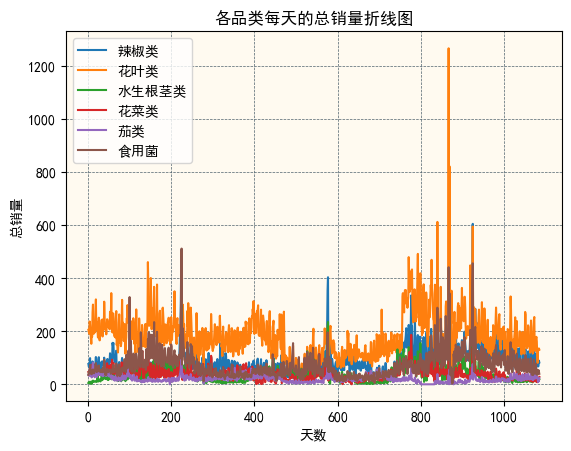

In [34]:
print(kind_day)
plt.plot(kind_day,label=kind_day.columns)
plt.title('各品类每天的总销量折线图')
plt.xlabel("天数")
plt.ylabel("总销量")
plt.legend()
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.savefig('./各品类每天的总销量折线图.png',dpi=300)
plt.show()

In [20]:
#分析附件二销售天数
df21 = df2.copy()
df21['销售日期'] = pd.to_datetime(df21['销售日期'])
df21['时间'] = 0
counter = 1
for index, row in df21.iterrows():
    if index == 0:
        df21.at[index, '时间'] = counter
    elif row['销售日期'] != df21.at[index - 1, '销售日期']:
        counter += 1
        df21.at[index, '时间'] = counter
    else:
        df21.at[index, '时间'] = counter
df21.insert(0, '时间', df21.pop('时间'))
df21.to_excel('output2.xlsx', index=False)

In [21]:
#各品类每日成本加成定价
item=0
day=df2['销售日期'][item].day
date=1
count_sale = [0]*6
price_day = [[0] * 6] * 1085
price_dayall = [0]*6
price_day = pd.DataFrame(0, index=range(1, 1086), columns=['辣椒类','花叶类','水生根茎类','花菜类','茄类','食用菌'])
price_day

,辣椒类,花叶类,水生根茎类,花菜类,茄类,食用菌
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
5,0,0,0,0,0,0
...,...,...,...,...,...,...
1081,0,0,0,0,0,0
1082,0,0,0,0,0,0
1083,0,0,0,0,0,0
1084,0,0,0,0,0,0


In [22]:
while(item<=878502):
    if(df2['品类'][item]=='辣椒类'):
        price_dayall[0]+=df2['销售单价(元/千克)'][item]*df2['销量(千克)'][item]
        count_sale[0]+=df2['销量(千克)'][item]
    elif(df2['品类'][item]=='花叶类'):
        price_dayall[1]+=df2['销售单价(元/千克)'][item]*df2['销量(千克)'][item] 
        count_sale[1]+=df2['销量(千克)'][item]
    elif(df2['品类'][item]=='水生根茎类'):
        price_dayall[2]+=df2['销售单价(元/千克)'][item]*df2['销量(千克)'][item]
        count_sale[2]+=df2['销量(千克)'][item]
    elif(df2['品类'][item]=='花菜类'):
        price_dayall[3]+=df2['销售单价(元/千克)'][item]*df2['销量(千克)'][item]
        count_sale[3]+=df2['销量(千克)'][item]
    elif(df2['品类'][item]=='茄类'):
        price_dayall[4]+=df2['销售单价(元/千克)'][item]*df2['销量(千克)'][item]
        count_sale[4]+=df2['销量(千克)'][item]
    elif(df2['品类'][item]=='食用菌'):
        price_dayall[5]+=df2['销售单价(元/千克)'][item]*df2['销量(千克)'][item]
        count_sale[5]+=df2['销量(千克)'][item]
    #判断是否跨日
    day1=day
    item+=1
    if(item==878502):
        if count_sale[0]!=0:
            price_day.at[date,'辣椒类']=price_dayall[0]/count_sale[0]
        if count_sale[1]!=0:
            price_day.at[date,'花叶类']=price_dayall[1]/count_sale[1]
        if count_sale[2]!=0:
            price_day.at[date,'水生根茎类']=price_dayall[2]/count_sale[2]
        if count_sale[3]!=0:
            price_day.at[date,'花菜类']=price_dayall[3]/count_sale[3]
        if count_sale[4]!=0:
            price_day.at[date,'茄类']=price_dayall[4]/count_sale[4]
        if count_sale[5]!=0:
            price_day.at[date,'食用菌']=price_dayall[5]/count_sale[5]        
        break
    day=df2['销售日期'][item].day         
    if day1!=day:
        #算品类均价
        if count_sale[0]!=0:
            price_day.at[date,'辣椒类']=price_dayall[0]/count_sale[0]
        if count_sale[1]!=0:
            price_day.at[date,'花叶类']=price_dayall[1]/count_sale[1]
        if count_sale[2]!=0:
            price_day.at[date,'水生根茎类']=price_dayall[2]/count_sale[2]
        if count_sale[3]!=0:
            price_day.at[date,'花菜类']=price_dayall[3]/count_sale[3]
        if count_sale[4]!=0:
            price_day.at[date,'茄类']=price_dayall[4]/count_sale[4]
        if count_sale[5]!=0:
            price_day.at[date,'食用菌']=price_dayall[5]/count_sale[5]
        
        count_sale = [0]*6
        price_dayall = [0]*6        
        date+=1

price_day

,辣椒类,花叶类,水生根茎类,花菜类,茄类,食用菌
1,9.906670,7.321202,14.491505,12.704331,4.998530,10.422791
2,10.137206,7.106526,11.548000,12.425915,5.344638,12.490806
3,10.437872,7.335747,8.012223,11.773172,5.466988,12.871566
4,10.167277,7.783183,21.833646,12.615177,5.737169,12.244586
5,10.317542,7.026290,10.000000,12.582147,6.654638,10.006745
...,...,...,...,...,...,...
1081,5.895477,5.347029,17.964407,14.000000,6.359310,5.473902
1082,6.299712,5.044781,15.986605,12.000000,7.976708,5.009094
1083,6.061937,4.842749,14.012538,12.332068,7.772078,4.612928
1084,6.244072,4.783032,17.064833,12.004022,7.501729,4.676408


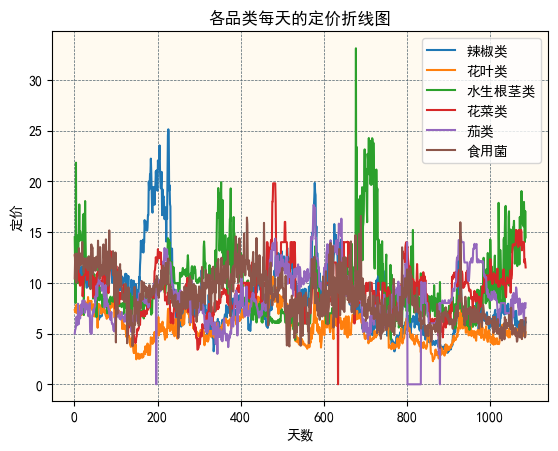

In [33]:
plt.plot(price_day,label=price_day.columns)
plt.title('各品类每天的定价折线图')
plt.xlabel("天数")
plt.ylabel("定价")
plt.legend()
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.savefig('./各品类每天的定价折线图.png',dpi=300)
plt.show()

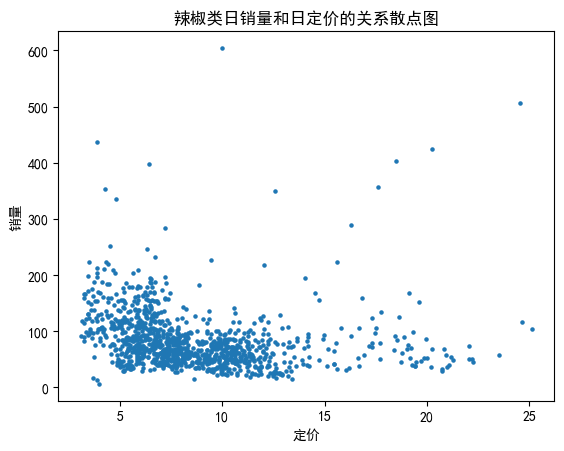

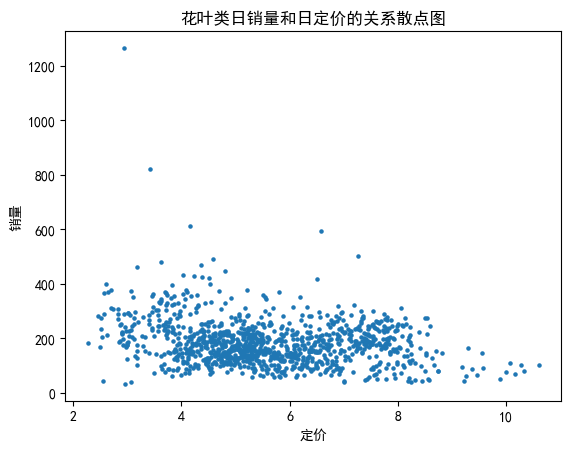

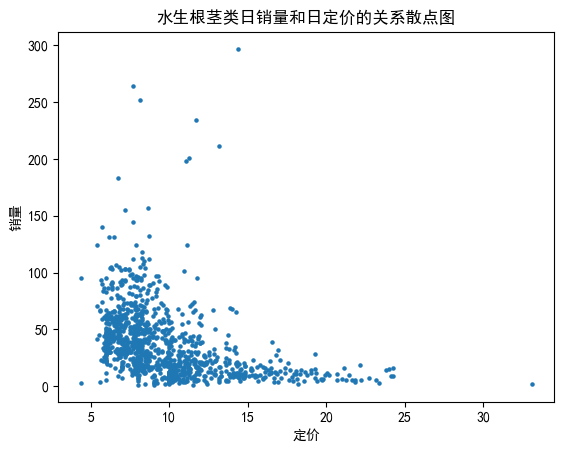

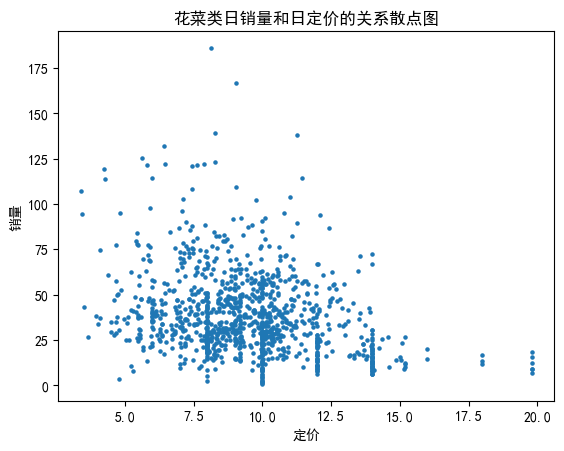

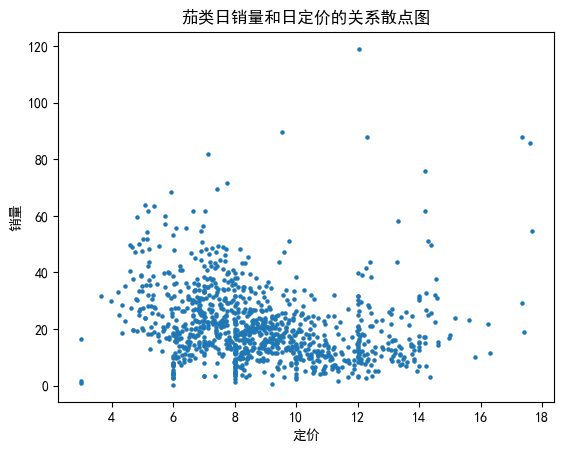

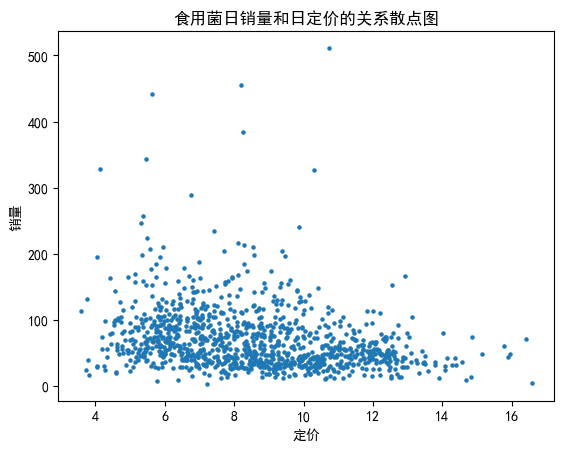

In [24]:
#合并
# price_day = price_day.rename_axis('Date').reset_index()
# kind_day = kind_day.rename_axis('Date').reset_index()
# price_sale = pd.merge(price_day, kind_day, on='Date')
price_sale1 = pd.concat([price_day["辣椒类"],kind_day["辣椒类"]], axis=1)
price_sale1.columns=['定价','销量']
price_sale1=price_sale1[price_sale1['定价'] != 0]
plt.scatter(price_sale1['定价'],price_sale1['销量'],s=5)
plt.xlabel('定价')
plt.ylabel('销量')
plt.title('辣椒类日销量和日定价的关系散点图')
plt.show()

price_sale2 = pd.concat([price_day["花叶类"],kind_day["花叶类"]], axis=1)
price_sale2.columns=['定价','销量']
price_sale2=price_sale2[price_sale2['定价'] != 0]
plt.scatter(price_sale2['定价'],price_sale2['销量'],s=5)
plt.xlabel('定价')
plt.ylabel('销量')
plt.title('花叶类日销量和日定价的关系散点图')
plt.show()

price_sale3 = pd.concat([price_day["水生根茎类"],kind_day["水生根茎类"]], axis=1)
price_sale3.columns=['定价','销量']
price_sale3=price_sale3[price_sale3['定价'] != 0]
plt.scatter(price_sale3['定价'],price_sale3['销量'],s=5)
plt.xlabel('定价')
plt.ylabel('销量')
plt.title('水生根茎类日销量和日定价的关系散点图')
plt.show()

price_sale4 = pd.concat([price_day["花菜类"],kind_day["花菜类"]], axis=1)
price_sale4.columns=['定价','销量']
price_sale4=price_sale4[price_sale4['定价'] != 0]
plt.scatter(price_sale4['定价'],price_sale4['销量'],s=5)
plt.xlabel('定价')
plt.ylabel('销量')
plt.title('花菜类日销量和日定价的关系散点图')
plt.show()

price_sale5 = pd.concat([price_day["茄类"],kind_day["茄类"]], axis=1)
price_sale5.columns=['定价','销量']
price_sale5=price_sale5[price_sale5['定价'] != 0]
plt.scatter(price_sale5['定价'],price_sale5['销量'],s=5)
plt.xlabel('定价')
plt.ylabel('销量')
plt.title('茄类日销量和日定价的关系散点图')
plt.show()

price_sale6= pd.concat([price_day["食用菌"],kind_day["食用菌"]], axis=1)
price_sale6.columns=['定价','销量']
price_sale6=price_sale6[price_sale6['定价'] != 0]
plt.scatter(price_sale6['定价'],price_sale6['销量'],s=5)
plt.xlabel('定价')
plt.ylabel('销量')
plt.title('食用菌日销量和日定价的关系散点图')
plt.show()

残差平方和： 2893141.291021178


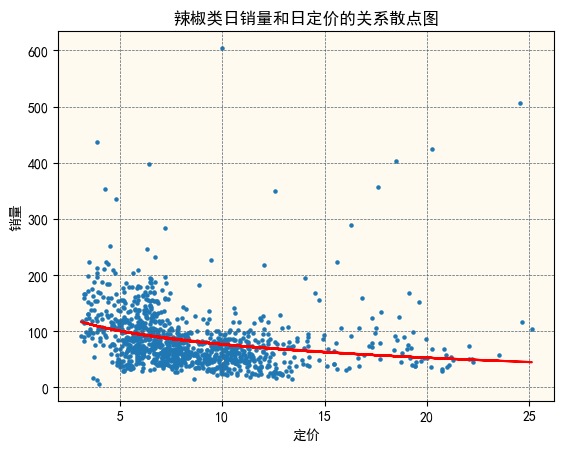

残差平方和： 7514854.688015562


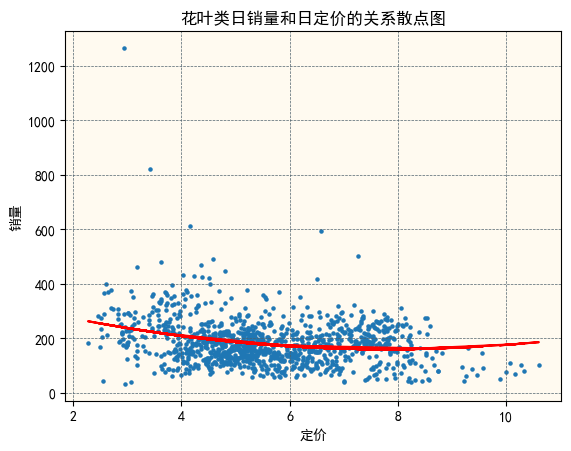

残差平方和： 904315.7319941402


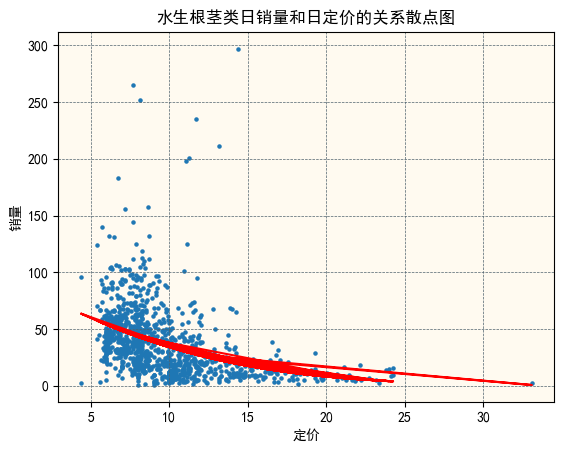

残差平方和： 508183.6280601579


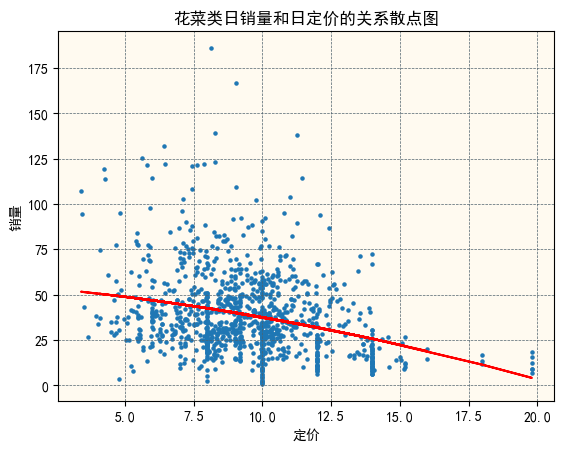

残差平方和： 163698.36915650417


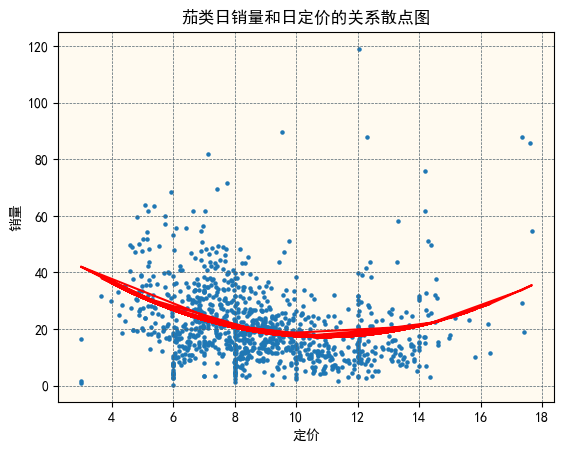

残差平方和： 2378173.5533609185


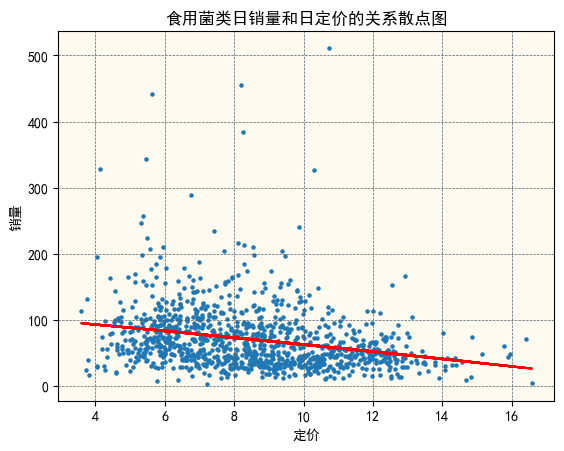

In [30]:
#最小二乘拟合
price_sale1
def exponential_func(x, a, b,c):
    return a * np.exp(b * x)+c

def power_func(x, a, b,c):
    return a * np.power(x, b)+c


def logarithmic_func(x, a, b,c):
    return a * np.log(b * x)+c

def polynomial_func(x, a, b, c):
    return a + b * x + c * x**2

def sigmoid_func(x, a, b,c):
    return a / (1 + np.exp(-b * (x)))+c

def gaussian_func(x, a, b, c):
    return a * np.exp(-(x - b)**2 / (2 * c**2))


params, covariance = curve_fit(logarithmic_func, price_sale1['定价'], price_sale1['销量'])
a, b, c = params
y_fit = logarithmic_func(price_sale1['定价'], a, b, c)
residuals = price_sale1['销量'] - y_fit
SSE = np.sum(residuals**2)
print('残差平方和：',SSE)
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.plot(price_sale1['定价'], y_fit, 'r-', label='Fitted Curve')
plt.scatter(price_sale1['定价'], price_sale1['销量'],s=5)
plt.xlabel('定价')
plt.ylabel('销量')
plt.title('辣椒类日销量和日定价的关系散点图')
plt.savefig('./辣椒类日销量和日定价的关系散点图.png',dpi=300)

plt.show()

params, covariance = curve_fit(polynomial_func, price_sale2['定价'], price_sale2['销量'])
a, b, c = params
y_fit = polynomial_func(price_sale2['定价'], a, b, c)
residuals = price_sale2['销量'] - y_fit
SSE = np.sum(residuals**2)
print('残差平方和：',SSE)
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.plot(price_sale2['定价'], y_fit, 'r-', label='Fitted Curve')
plt.scatter(price_sale2['定价'], price_sale2['销量'],s=5)
plt.xlabel('定价')
plt.ylabel('销量')
plt.title('花叶类日销量和日定价的关系散点图')
plt.savefig('./花叶类日销量和日定价的关系散点图.png',dpi=300)

plt.show()

params, covariance = curve_fit(gaussian_func, price_sale3['定价'], price_sale3['销量'])
a, b, c = params
y_fit = gaussian_func(price_sale3['定价'], a, b, c)
residuals = price_sale3['销量'] - y_fit
SSE = np.sum(residuals**2)
print('残差平方和：',SSE)
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.plot(price_sale3['定价'], y_fit, 'r-', label='Fitted Curve')
plt.scatter(price_sale3['定价'], price_sale3['销量'],s=5)
plt.xlabel('定价')
plt.ylabel('销量')
plt.title('水生根茎类日销量和日定价的关系散点图')
plt.savefig('./水生根茎类日销量和日定价的关系散点图.png',dpi=300)

plt.show()

params, covariance = curve_fit(polynomial_func, price_sale4['定价'], price_sale4['销量'])
a, b, c = params
y_fit = polynomial_func(price_sale4['定价'], a, b, c)
residuals = price_sale4['销量'] - y_fit
SSE = np.sum(residuals**2)
print('残差平方和：',SSE)
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.plot(price_sale4['定价'], y_fit, 'r-', label='Fitted Curve')
plt.scatter(price_sale4['定价'], price_sale4['销量'],s=5)
plt.xlabel('定价')
plt.ylabel('销量')
plt.title('花菜类日销量和日定价的关系散点图')
plt.savefig('./花菜类日销量和日定价的关系散点图.png',dpi=300)
plt.show()

params, covariance = curve_fit(polynomial_func, price_sale5['定价'], price_sale5['销量'])
a, b, c = params
y_fit = polynomial_func(price_sale5['定价'], a, b, c)
residuals = price_sale5['销量'] - y_fit
SSE = np.sum(residuals**2)
print('残差平方和：',SSE)
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.plot(price_sale5['定价'], y_fit, 'r-', label='Fitted Curve')
plt.scatter(price_sale5['定价'], price_sale5['销量'],s=5)
plt.xlabel('定价')
plt.ylabel('销量')
plt.title('茄类日销量和日定价的关系散点图')
plt.savefig('./茄类日销量和日定价的关系散点图.png',dpi=300)

plt.show()

params, covariance = curve_fit(polynomial_func, price_sale6['定价'], price_sale6['销量'])
a, b, c = params
y_fit = polynomial_func(price_sale6['定价'], a, b, c)
residuals = price_sale6['销量'] - y_fit
SSE = np.sum(residuals**2)
print('残差平方和：',SSE)
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facec//[/[polor('#FFFAF0')
plt.plot(price_sale6['定价'], y_fit, 'r-', label='Fitted Curve')
plt.scatter(price_sale6['定价'], price_sale6['销量'],s=5)
plt.xlabel('定价')
plt.ylabel('销量')
plt.title('食用菌类日销量和日定价的关系散点图')
plt.savefig('./食用菌类日销量和日定价的关系散点图.png',dpi=300)
plt.show()

In [27]:
model = LinearRegression()

# 拟合模型
model.fit(price_sale2['定价'].to_frame(), price_sale2['销量'])
y_pred = model.predict(price_sale2['定价'].to_frame())
# 计算SSE
sse = np.sum((y_pred - price_sale2['销量'])**2)
print("SSE:", sse)
print("回归系数 (斜率):", model.coef_)
print("截距:", model.intercept_)

model.fit(price_sale4['定价'].to_frame(), price_sale4['销量'])
y_pred = model.predict(price_sale4['定价'].to_frame())
# 计算SSE
sse = np.sum((y_pred - price_sale4['销量'])**2)
print("SSE:", sse)
print("回归系数 (斜率):", model.coef_)
print("截距:", model.intercept_)

model.fit(price_sale5['定价'].to_frame(), price_sale5['销量'])
y_pred = model.predict(price_sale5['定价'].to_frame())
# 计算SSE
sse = np.sum((y_pred - price_sale5['销量'])**2)
print("SSE:", sse)
print("回归系数 (斜率):", model.coef_)
print("截距:", model.intercept_)

model.fit(price_sale6['定价'].to_frame(), price_sale6['销量'])
y_pred = model.predict(price_sale6['定价'].to_frame())
# 计算SSE
sse = np.sum((y_pred - price_sale6['销量'])**2)
print("SSE:", sse)
print("回归系数 (斜率):", model.coef_)
print("截距:", model.intercept_)

SSE: 7615794.719199384
回归系数 (斜率): [-13.27476702]
截距: 257.33387499021046
SSE: 508905.0557953194
回归系数 (斜率): [-2.68236432]
截距: 63.809488052096405
SSE: 174907.81154010844
回归系数 (斜率): [-1.01572421]
截距: 30.31684528967995
SSE: 2378282.6468318207
回归系数 (斜率): [-5.17956405]
截距: 114.5455850657614


#### 给出日补货总量和定价策略

In [ ]:
data = pd.DataFrame(df2)
index = [['2023-05-01','2023-06-30']]

result = []

for time in index:
    ans = data[(data['销售日期'] >= time[0]) & (data['销售日期'] <= time[1])].groupby(['销售日期','品类'])['销量'].sum().reset_index()
    result.append(ans)
result = pd.concat(result, axis=0, ignore_index=True)

for index,row in result.iterrows():
    time = row['销售日期'].strftime('%Y-%m-%d')
    result.at[index, '星期'] = pendulum.parse(time).day_of_week
result['星期'] = result['星期'].replace(0, 7)

result['星期'] = result['星期'].astype(int)
result

In [ ]:
merged_df = df2.merge(df3[['日期', '单品编码', '批发价格']], how='left', left_on=['销售日期', '单品编码'], right_on=['日期', '单品编码'])

# 填充缺失值，将'批发价格'列中的NaN值替换为0或其他默认值
merged_df['批发价格'].fillna(0, inplace=True)

# 新增一列'批发价格'到df2中，并赋值为合并后的批发价格列
df2['批发价格'] = merged_df['批发价格']
df2.head()

In [ ]:
data = pd.DataFrame(df2)
index = [['2023-05-01','2023-06-30']]

result2 = pd.DataFrame(columns=['销售日期', '品类', '销售总额'])

# 遍历日期范围
for time in index:
    df =  data[(data['销售日期'] >= time[0]) & (data['销售日期'] <= time[1])]
    group_result = df.groupby(['销售日期','品类'])['销量','批发价格'].apply(lambda x: (x['销量'] * x['批发价格']).sum()).reset_index()
    group_result = group_result.rename(columns={0: '销售总额'})
    
    # 将每次计算的结果添加到结果DataFrame中
    result2 = pd.concat([result2, group_result], ignore_index=True)

# 输出结果
result2

In [ ]:
cost = result2['销售总额'] / result['销量']
cost = pd.DataFrame({'品类':result['品类'],'成本':cost})
cost

In [ ]:
cost = cost.groupby('品类')['成本'].mean().reset_index()
cost

In [ ]:
code_to_category = df1.set_index('单品编码')['分类名称'].to_dict()
# 使用 map 函数将单品编码映射到分类名称，并创建新的一列
df4['分类名称'] = df4['单品编码'].map(code_to_category)
df4

In [ ]:
sale = pd.read_excel('./平均定价.xlsx')
price_week = pd.DataFrame()
index = [[1024,1084]]
for time in index:
    price_week = price_week.append(sale.loc[time[0]:time[1]], ignore_index=True)

price_week
price_week['销售日期'] = turnover['销售日期']
for index,row in price_week.iterrows():
    time = row['销售日期'].strftime('%Y-%m-%d')
    price_week.at[index, '星期'] = pendulum.parse(time).day_of_week
price_week['星期'] = price_week['星期'].replace(0, 7)
price_week['星期'] = price_week['星期'].astype(int)
price_week

turnover = pd.DataFrame({'销售日期':[],
                         '辣椒类':[],
                         '花叶类':[],
                         '水生根茎类':[],
                         '花菜类':[],
                         '茄类':[],
                         '食用菌':[]})

previous_date = None

for index, row in result.iterrows():
    current_date = row['销售日期']
    if current_date != previous_date or index == 0:
        turnover = turnover.append({'销售日期': current_date}, ignore_index=True)
    turnover.loc[turnover['销售日期'] == current_date, row['品类']] = row['销量']
    previous_date = current_date

# 显示生成的 DataFrame
turnover

for index,row in turnover.iterrows():
    time = row['销售日期'].strftime('%Y-%m-%d')
    turnover.at[index, '星期'] = pendulum.parse(time).day_of_week
turnover['星期'] = turnover['星期'].replace(0, 7)
turnover['星期'] = turnover['星期'].astype(int)
turnover

plt.figure(figsize=(15,40))
plt.subplot(6,2,1)
plt.plot( turnover['辣椒类'].index, turnover['辣椒类'].values)
plt.subplot(6,2,2)
plt.plot( price_week['辣椒类'].index, price_week['辣椒类'].values)

plt.subplot(6,2,3)
plt.plot( turnover['花叶类'].index, turnover['花叶类'].values)
plt.subplot(6,2,4)
plt.plot( price_week['花叶类'].index, price_week['花叶类'].values)

plt.subplot(6,2,5)
plt.plot( turnover['花菜类'].index, turnover['花菜类'].values)
plt.subplot(6,2,6)
plt.plot( price_week['花菜类'].index, price_week['花菜类'].values)

plt.subplot(6,2,7)
plt.plot( turnover['水生根茎类'].index, turnover['水生根茎类'].values)
plt.subplot(6,2,8)
plt.plot( price_week['水生根茎类'].index, price_week['水生根茎类'].values)

plt.subplot(6,2,9)
plt.plot( turnover['茄类'].index, turnover['茄类'].values)
plt.subplot(6,2,10)
plt.plot( price_week['茄类'].index, price_week['茄类'].values)

plt.subplot(6,2,11)
plt.plot( turnover['食用菌'].index, turnover['食用菌'].values)
plt.subplot(6,2,12)
plt.plot( price_week['食用菌'].index, price_week['食用菌'].values)

plt.show()

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(121)
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.plot( turnover['花菜类'].index, turnover['花菜类'].values)
plt.xlabel('天数')
plt.ylabel('销量')
plt.title('花菜类近60天销量')
plt.subplot(122)
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.plot( price_week['花菜类'].index, price_week['花菜类'].values)
plt.xlabel('天数')
plt.ylabel('定价')
plt.title('花菜类近60天定价')
plt.savefig('./花菜类60天销量与定价趋势.png',dpi=300)
plt.show()

In [ ]:
from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.model_selection import train_test_split

data = turnover.copy()
data['销售日期'] = pd.to_datetime(data['销售日期'])
data.set_index('销售日期', inplace=True)
# 将销售数据转换为时间序列
sales_series = data['食用菌']

# 使用ExponentialSmoothing模型预测未来七天
fit = ExponentialSmoothing(sales_series, trend='add', seasonal='add', seasonal_periods=7).fit()
forecast = fit.forecast(steps=7)

# 原数据
sales_series = data['食用菌']

# 预测数据
forecast = fit.forecast(steps=7)

绘制折线图
plt.figure(figsize=(10, 6))
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.plot(sales_series.index, sales_series.values, label='原数据', marker='o')
plt.plot(forecast.index, forecast.values, label='预测数据', marker='x')
plt.xlabel('销售日期')
plt.ylabel('销售量')
plt.title('食用菌销售量原数据和预测数据')
plt.legend()
plt.grid(True)
plt.savefig('./食用菌销售量原数据和预测数据.png',dpi=300)
plt.show()
forecast

In [ ]:
forecast_table = pd.DataFrame()#以上代码重复6次，打印出结果因此这里省略，生成结果在支撑列表forecast_table。xlsx

In [ ]:
rho, p_value = stats.spearmanr(price_week['花菜类'], turnover['花菜类'])

if p_value < 0.05:
    print(f"Spearman秩相关系数：{p_value:.2f}，关联显著")
else:
    print(f"Spearman秩相关系数：{p_value:.2f}，关联不显著")
#最小二乘拟合
def exponential_func(x, a, b,c):
    return a * np.exp(b * x)+c

def power_func(x, a, b,c):
    return a * np.power(x, b)+c


def logarithmic_func(x, a, b,c):
    return a * np.log(b * x)+c

def polynomial_func(x, a, b, c):
    return a + b * x + c * x**2

def sigmoid_func(x, a, b,c):
    return a / (1 + np.exp(-b * (x)))+c

def gaussian_func(x, a, b, c):
    return a * np.exp(-(x - b)**2 / (2 * c**2))

params, covariance = curve_fit(polynomial_func, price_week['花菜类'], turnover['花菜类'])
a, b, c = params
y_fit = polynomial_func(price_week['花菜类'], a, b, c)
residuals = turnover['花菜类'] - y_fit
SSE = np.sum(residuals**2)
print('残差平方和：',SSE)
plt.figure(figsize=(8, 6))
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.scatter(price_week['花菜类'],turnover['花菜类'],s=10)
plt.plot(price_week['花菜类'], y_fit, 'r-', label='Fitted Curve')
plt.xlabel('定价')
plt.ylabel('销量')
plt.title('花菜类销量价格曲线')
plt.savefig('./花菜类销量价格曲线.png',dpi=300)
plt.show()
print(a,b,c)

In [65]:
import sympy as sp

# 定义变量
x = sp.symbols('x')

# 定义三次函数

b = 0.295  # 二次项系数
c = -9.8  # 一次项系数
d = 97   # 常数项系数
cubic_function = b * x**2 + c * x + d

# 计算一阶导数
derivative = sp.diff(cubic_function, x)
print(derivative)
# 解一阶导数等于零的方程，找到极值点的x坐标
critical_points_x = sp.solve(derivative, x)

# 计算极值点的y坐标（函数值）
extrema = [(point, cubic_function.subs(x, point)) for point in critical_points_x]

# 输出结果
for point in extrema:
    print(f"极值点 ({point[0]}, {point[1]})")


0.59*x - 9.8
极值点 (16.6101694915254, 15.6101694915254)


In [63]:
# 定义三次函数
# 例如：f(x) = ax^3 + bx^2 + cx + d，替换为你的三次函数表达式
a =0.295
b = -12.57
c =189.022
d = -910.83

# 生成x坐标的值
x = np.linspace(-100, 100, 400)  # 在指定范围内生成均匀分布的x坐标值

# 计算对应x坐标的y值
x=16.5
y = a * x**3 + b * x**2 + c * x + d
print(y)
# # 绘制图形
# plt.plot(x, y, label='三次函数')
# plt.xlabel('x轴')
# plt.ylabel('y轴')
# plt.title('三次函数的图形')
# plt.grid(True)
# plt.legend()
# plt.show()

111.027375


In [ ]:
data = df2.copy()
data['销售日期'] = pd.to_datetime(data['销售日期'])
data.set_index('销售日期', inplace=True)
data = data.loc['2023-05-01':'2023-06-30'].reset_index()

data = data.merge(df4[['单品编码', '损耗率(%)']], on='单品编码', how='left')
data.head()

In [ ]:
result = data.groupby('品类').apply(lambda x: ((x['销量'] * x['损耗率(%)'] / 100) / (1 - x['损耗率(%)'] / 100)).sum()).reset_index()
result.columns = ['品类', 'ans']

# 打印结果
result

In [ ]:
result2 = data.groupby('品类').apply(lambda x: (x['销量'] / (1 - x['损耗率(%)'] / 100)).sum()).reset_index()
result2.columns = ['品类', 'ans']

# 打印结果
result2

In [ ]:
ans = (result['ans']/result2['ans'])*100
loss = pd.DataFrame({'品类':result['品类'].values,
                    '品类亏损率':ans})
loss

In [ ]:
ans1 = (data['销售单价'] * data['销量']) - ((data['销量'] / (1 - (data['损耗率(%)'] / 100))) * data['批发价格'])
ans1 = ans1.sum()
ans2 = ((data['销量'] / (1 - (data['损耗率(%)'] / 100))) * data['批发价格'])
ans2 = ans2.sum()
print(ans1/ans2)

price = pd.DataFrame() 
cols = forecast_table.columns.values
for col in cols:
    x = []
    a1 = forecast_table[col][0]
    a2 = forecast_table[col][1]
    a3 = forecast_table[col][2]
    a4 = forecast_table[col][3]
    a5 = forecast_table[col][4]
    a6 = forecast_table[col][5]
    a7 = forecast_table[col][6]
    c = cost[cost['品类'] == col]['成本'].values.item()
    x.append((1.4*c*(a1+a2+a3+a4+a5+a6+a7)*(1/(1 - loss[loss['品类'] == col]['品类亏损率'].values.item()/100)))/(a1+(a2**2/a1)+(a3**2/a1)+(a4**2/a1)+(a5**2/a1)+(a6**2/a1)+(a7**2/a1)))
    x.append((a2/a1)*x[0])
    x.append((a3/a1)*x[0])
    x.append((a4/a1)*x[0])
    x.append((a5/a1)*x[0])
    x.append((a6/a1)*x[0])
    x.append((a7/a1)*x[0])
    price[col] = x
    
price['花菜类'] = [16.5]*7

print(price)

#品类未来7天的订货量
order = pd.DataFrame()
cols = forecast_table.columns.values
for col in cols:
    order[col] = forecast_table[col]/(1 - loss[loss['品类'] == col]['品类亏损率'].values.item()/100)
order

#品类未来7天的利润
profit = pd.DataFrame()
cols = forecast_table.columns.values
for col in cols:
    profit[col] = forecast_table[col]*(price[col] - cost[cost['品类'] == col]['成本'].values.item()/(1 - loss[loss['品类'] == col]['品类亏损率'].values.item()/100))

#总利润
profit['总收入'] = profit.sum(axis=1)
profit
profit['总收入'].sum()


### 问题3

#### 使商超收益最大

In [ ]:
data = pd.read_excel('./7日内附表2数据.xlsx')
data = data[data['是否打折销售'] != '是']
data.head()

goods = data['单品名称'].unique()

data['单品利润率'] = (data['销售单价'] - (data['批发价格'] / (1 - data['损耗率(%)']/100))) / data['批发价格']
profit_rate = data.groupby('单品名称')['单品利润率'].mean()
profit_rate = pd.DataFrame(profit_rate)
profit_rate.to_excel('./7天单品利润率.xlsx')

In [116]:
df22=pd.read_excel('7日流水数据_去除打折.xlsx')


In [159]:
#统计7天内出现不同单品分别是谁
unique_products = df22['单品名称'].unique()
products_count=unique_products.size
# 打印结果
print(products_count)
print(unique_products)


48
['小皱皮(份)' '竹叶菜' '苋菜' '云南生菜(份)' '上海青' '外地茼蒿' '西峡花菇(1)' '圆茄子(2)' '芜湖青椒(1)'
 '云南油麦菜(份)' '红椒(2)' '海鲜菇(包)' '西兰花' '净藕(1)' '小米椒(份)' '红薯尖' '紫茄子(2)'
 '枝江青梗散花' '奶白菜' '菜心' '虫草花(份)' '长线茄' '金针菇(盒)' '小青菜(1)' '木耳菜' '双孢菇(盒)'
 '高瓜(1)' '洪湖藕带' '青茄子(1)' '螺丝椒(份)' '螺丝椒' '菠菜' '蟹味菇与白玉菇双拼(盒)' '菱角'
 '姜蒜小米椒组合装(小份)' '娃娃菜' '七彩椒(2)' '菠菜(份)' '红莲藕带' '青红杭椒组合装(份)' '青线椒(份)'
 '云南油麦菜' '高瓜(2)' '云南生菜' '白玉菇(袋)' '野生粉藕' '紫茄子(1)' '木耳菜(份)']


In [160]:
#单品类日内销售总量
unique_products = df22['单品名称'].unique()
sale_day = pd.DataFrame(0, index=range(1, 8), columns=unique_products)
item=0
day=df22['销售日期'][item].day
date=1
while(item<=3122):
    sale_day[df22['单品名称'][item]][date] += df22['销量'][item]
    #判断是否跨日
    day1=day
    if item==3122:
        sale_day[df22['单品名称'][item]][date] += df22['销量'][item]
        break
    item+=1       
    day=df22['销售日期'][item].day
    if day1!=day:
        
        date+=1
sale_day

C:\Users\changeable\AppData\Local\Temp\ipykernel_10276\479329289.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sale_day[df22['单品名称'][item]][date] += df22['销量'][item]


,小皱皮(份),竹叶菜,苋菜,云南生菜(份),上海青,外地茼蒿,西峡花菇(1),圆茄子(2),芜湖青椒(1),云南油麦菜(份),...,红莲藕带,青红杭椒组合装(份),青线椒(份),云南油麦菜,高瓜(2),云南生菜,白玉菇(袋),野生粉藕,紫茄子(1),木耳菜(份)
1,16,16.569,14.396,49,5.127,3.680,6.180,0.867,17.986,24,...,0.862,1,1,0.000,0.000,0.000,0,0.000,0.000,0
2,7,13.941,9.824,23,1.383,0.000,4.271,0.616,11.883,13,...,0.579,1,0,4.232,1.589,0.557,0,0.000,0.000,0
3,14,12.022,7.777,2,1.420,1.862,3.582,0.000,10.334,5,...,0.349,0,1,0.573,0.289,7.971,1,0.000,0.000,0
4,4,14.095,11.061,22,1.823,0.996,3.708,0.553,17.095,15,...,0.218,4,0,0.293,0.000,0.251,0,1.441,0.512,0
5,6,13.151,3.809,32,5.553,0.000,3.742,2.209,11.342,12,...,1.037,2,0,0.000,0.000,0.000,1,0.000,0.000,0
6,7,10.415,8.868,25,4.687,0.000,4.314,1.822,15.098,22,...,0.830,1,0,0.000,0.779,2.904,0,0.767,0.512,0
7,9,12.884,6.726,34,7.036,0.000,6.572,1.376,15.896,23,...,0.721,4,0,0.000,0.000,0.000,0,0.231,0.000,1


In [161]:
#单品类7日内销售总量
unique_products = df22['单品名称'].unique()
sale = pd.DataFrame(0, index=unique_products,columns=['销售总量'])
item=0
while(item<=3122):
    sale['销售总量'][df22['单品名称'][item]]+= df22['销量'][item]
    item+=1       

sale.to_excel('1.xlsx',index=True)

In [162]:
#单品类7日内销售总利润

unique_products = df22['单品名称'].unique()
sale_day = pd.DataFrame(0, index=range(1, 8), columns=unique_products)
item=0
day=df22['销售日期'][item].day
date=1
while(item<=3122):
    sale_day[df22['单品名称'][item]][date] += df22['销量'][item]*(df22['销售单价'][item]-df22['批发价格'][item]/(1-df22['损耗率(%)'][item]/100))
    #判断是否跨日
    day1=day
    if item==3122:
        sale_day[df22['单品名称'][item]][date] += df22['销量'][item]*(df22['销售单价'][item]-df22['批发价格'][item]/(1-df22['损耗率(%)'][item]/100))
        break
    item+=1       
    day=df22['销售日期'][item].day
    if day1!=day:
        
        date+=1
profit=pd.DataFrame(sale_day.sum(), columns=["总利润"])
profit.to_excel('2.xlsx',index=True)

C:\Users\changeable\AppData\Local\Temp\ipykernel_10276\1338676718.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sale_day[df22['单品名称'][item]][date] += df22['销量'][item]*(df22['销售单价'][item]-df22['批发价格'][item]/(1-df22['损耗率(%)'][item]/100))


In [ ]:
topsis = pd.read_excel('./单品重要性分析.xlsx')
topsis.head()

In [ ]:
df = topsis.copy()
df.head()
numeric_columns = df.columns[1:]
df[numeric_columns] = df[numeric_columns].astype(float)

# 步骤1：数据标准化
df_normalized = df.copy()
for col in df.columns[1:]:
    df_normalized[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# 步骤2：计算信息熵和权重
df_normalized = df_normalized[['销售总量', '总利润', '单品利润率']]
entropy = -np.sum(df_normalized[numeric_columns] * np.log(df_normalized[numeric_columns]), axis=0)
weights = (1 - entropy) / np.sum(1 - entropy)


# 步骤3：构建决策矩阵，假设选择了销售总量、总利润和单品利润率三个指标
decision_matrix = df_normalized[['销售总量', '总利润', '单品利润率']]

# 步骤4：计算理想解和负理想解
ideal_positive = decision_matrix.max().values
ideal_negative = decision_matrix.min().values

# 步骤5：计算距离
positive_distances = np.sqrt(np.sum((decision_matrix - ideal_positive) ** 2, axis=1))
negative_distances = np.sqrt(np.sum((decision_matrix - ideal_negative) ** 2, axis=1))

# 步骤6：性能评估
scores = negative_distances / (negative_distances + positive_distances)

# 步骤7：排名
df['TOPSIS得分'] = scores
ranked_df = df.sort_values(by='TOPSIS得分', ascending=False).reset_index(drop = True)
ranked_df['排名'] = range(1,49)

In [ ]:
sale_daycount = data.groupby('销售日期')['销量'].sum()
plt.plot(sale_daycount.index,sale_daycount.values)
plt.show()

In [ ]:
data = df2.copy()
data['销售日期'] = pd.to_datetime(data['销售日期'])
data.set_index('销售日期', inplace=True)
data = data.loc['2023-05-01':'2023-06-30'].reset_index()

sale = data.groupby('销售日期')['销量'].sum()
plt.plot(sale.index,sale.values)
plt.show()
sale = sale.reset_index()

In [ ]:
data = sale.copy()
data['销售日期'] = pd.to_datetime(data['销售日期'])
data.set_index('销售日期', inplace=True)
# 将销售数据转换为时间序列
sales_series = data['销量']

# 使用ExponentialSmoothing模型预测未来七天
fit = ExponentialSmoothing(sales_series, trend='add', seasonal='add', seasonal_periods=7).fit()
forecast = fit.forecast(steps=7)

# 原数据
sales_series = data['销量']

# 预测数据
forecast = fit.forecast(steps=7)

plt.figure(figsize=(10, 6))
plt.grid(ls = "--", lw = 0.5, color = "#4E616C")
plt.gca().set_facecolor('#FFFAF0')
plt.plot(sales_series.index, sales_series.values, label='原数据', marker='o')
plt.plot(forecast.index, forecast.values, label='预测数据', marker='x')
plt.xlabel('销售日期')
plt.ylabel('销量')
plt.title('销量原数据和预测数据')
plt.legend()
plt.grid(True)
plt.savefig('./销量原数据和预测数据.png',dpi=300)
plt.show()
forecast[0]

In [ ]:
for index,row in data.iterrows():
    time = row['销售日期'].strftime('%Y-%m-%d')
    data.at[index, '星期'] = pendulum.parse(time).day_of_week
data['星期'] = data['星期'].replace(0, 7)
data['星期'] = data['星期'].astype(int)
data.head()

In [ ]:
data = data[data['星期'] == 6]
day6_sale = data.groupby('单品名称')['销量'].sum()/8
day6_sale = day6_sale.reset_index()
day6_sale = day6_sale.sort_values(by='销量', ascending=False).reset_index(drop = True)
day6_sale.head()

In [ ]:
# day6_sale = day6_sale.merge(ranked_df[['单品名称', '排名']], on='单品名称', how='left')
# day6_sale = day6_sale.dropna(subset = ['排名']).reset_index(drop = True)
# day6_sale = day6_sale.sort_values(by = '排名').reset_index(drop = True)
# day6_sale = day6_sale.sort_values(by = '销量').reset_index(drop = True)
day6_sale['销量占比'] = day6_sale['销量']/day6_sale['销量'].sum()
day6_sale

In [ ]:
sale_list = []
sale_list = [item for item in day6_sale.loc[0:5]['单品名称'].values]

sale_list += [item for item in ranked_df.loc[0:15]['单品名称'].values]

sale_list = set(sale_list)
len(sale_list)

sale_list

lst

for item in lst:
    tmp_set = set(item)
    if(tmp_set.intersection(sale_list)):
        flag = 1
    else:
        flag = 0
    for tmp in item:
        if(tmp in ranked_df['单品名称'].values and flag == 1):
            sale_list.add(tmp)

sale_list = sale_list.union(set([item for item in ranked_df.loc[16:28]['单品名称'].values]))
sale_list

sale_list = list(sale_list)
sale_list = pd.DataFrame({'单品名称':sale_list})
sale_list

sale_list = sale_list.merge(ranked_df[['单品名称', '排名']], on='单品名称', how='left').reset_index(drop = True)

sale_list = sale_list.sort_values(by = '排名').reset_index(drop = True)
sale_list

sale_list =  sale_list.merge(df1[['单品名称', '分类名称']], on='单品名称', how='left').reset_index(drop = True)
sale_list

data = pd.read_excel('./单品重要性分析.xlsx')
sale_list = sale_list.merge(data[['单品名称','销售总量']],on = '单品名称', how = 'left').reset_index(drop = True)
sale_list

sale_list['销售占比'] = sale_list['销售总量']/sale_list['销售总量'].sum()

total_sale = 463.8273067734855
sale_list['预测销量'] = sale_list['销售占比']*total_sale
sale_list

sale_list = sale_list.merge(df4[['单品名称','损耗率(%)']], on = '单品名称', how = 'left').reset_index(drop = True)
sale_list

sale_list['订货量'] = sale_list['预测销量']/(1 - sale_list['损耗率(%)']/100)
sale_list

data = df3.copy()
data['日期'] = pd.to_datetime(data['日期'])
data.set_index('日期', inplace=True)
data = data.loc['2023-06-24':'2023-06-30'].reset_index()
data

mean_price = data.groupby('单品名称')['批发价格'].mean().reset_index()
sale_list = sale_list.merge(mean_price[['单品名称','批发价格']], on = '单品名称', how = 'left').reset_index(drop = True)
sale_list

sale_list = sale_list.drop('定价',axis = 1)

data = df2.copy()
data['销售日期'] = pd.to_datetime(data['销售日期'])
data.set_index('销售日期', inplace=True)
data = data.loc['2023-06-24':'2023-06-30'].reset_index()
data

danjia = data.groupby('单品名称')['销售单价'].mean().reset_index()
sale_list = sale_list.merge(danjia, on = '单品名称', how = 'left')
sale_list

sale_list.loc[sale_list['订货量'] < 2.5, '订货量'] = 2.5

sale_list['利润'] = sale_list['销售总量']*sale_list['销售单价'] - sale_list['订货量']*sale_list['批发价格']
sale_list

#得出
sale_list['利润'].sum()

sale_list['订货量'].sum()